In [1]:
from pathlib import Path

project = Path(
    r"C:\Users\manue\.codex\.chatgpt-projects\g-p-6a6dfe28cae48191a347367c8a39fae6\Who Moderates Europe"
)

print("Project folder found:", project.is_dir())

Project folder found: True


In [3]:
raw_folder = project / "01_data_raw"
files = sorted(raw_folder.glob("*.zip"))

print("Monthly files found:", len(files))

for file in files[:3]:
    print(file.name)

Monthly files found: 24
aggregated-simple-2024-01-01-parquet.zip
aggregated-simple-2024-02-01-parquet.zip
aggregated-simple-2024-03-01-parquet.zip


In [4]:
from zipfile import ZipFile

with ZipFile(files[0]) as archive:
    data_files = [
        name for name in archive.namelist()
        if name.endswith(".parquet")
    ]

print("Month:", files[0].name)
print("Data files inside:", len(data_files))
print("First data file:", data_files[0])

Month: aggregated-simple-2024-01-01-parquet.zip
Data files inside: 25
First data file: aggregated-simple.parquet/created_at_month=2024-01-01/part-00009-ade60f58-0e3e-43c2-b992-5265288a5795.c000.snappy.parquet


In [5]:
import pandas as pd
from io import BytesIO

with ZipFile(files[0]) as archive:
    table_bytes = archive.read(data_files[0])

df = pd.read_parquet(BytesIO(table_bytes))

print("Rows and columns:", df.shape)
display(df.head())

Rows and columns: (1226, 31)


,automated_decision,automated_detection,category,CONTENT_TYPE_APP,CONTENT_TYPE_AUDIO,CONTENT_TYPE_IMAGE,CONTENT_TYPE_PRODUCT,CONTENT_TYPE_SYNTHETIC_MEDIA,CONTENT_TYPE_TEXT,CONTENT_TYPE_VIDEO,...,DECISION_VISIBILITY_CONTENT_DISABLED,DECISION_VISIBILITY_CONTENT_DEMOTED,DECISION_VISIBILITY_CONTENT_AGE_RESTRICTED,DECISION_VISIBILITY_CONTENT_INTERACTION_RESTRICTED,DECISION_VISIBILITY_CONTENT_LABELLED,DECISION_VISIBILITY_OTHER,platform_name,created_at,source_type,count
0,AUTOMATED_DECISION_PARTIALLY,No,STATEMENT_CATEGORY_SCOPE_OF_PLATFORM_SERVICE,False,False,False,False,False,True,False,...,False,False,False,True,False,False,Amazon,2024-01-11,SOURCE_TYPE_OTHER_NOTIFICATION,222
1,AUTOMATED_DECISION_FULLY,Yes,STATEMENT_CATEGORY_ILLEGAL_OR_HARMFUL_SPEECH,False,False,False,False,False,False,True,...,False,False,False,False,False,True,TikTok,2024-01-09,SOURCE_VOLUNTARY,613
2,AUTOMATED_DECISION_FULLY,Yes,STATEMENT_CATEGORY_ILLEGAL_OR_HARMFUL_SPEECH,False,False,True,False,False,True,False,...,False,False,False,False,False,False,Google Maps,2024-01-01,SOURCE_VOLUNTARY,480
3,AUTOMATED_DECISION_FULLY,Yes,STATEMENT_CATEGORY_INTELLECTUAL_PROPERTY_INFRI...,False,False,False,True,False,False,False,...,False,False,False,False,False,False,AliExpress,2024-01-20,SOURCE_VOLUNTARY,452
4,AUTOMATED_DECISION_FULLY,Yes,STATEMENT_CATEGORY_SCOPE_OF_PLATFORM_SERVICE,False,False,False,False,False,False,False,...,True,False,False,False,False,False,Google Maps,2024-01-26,SOURCE_VOLUNTARY,839


In [6]:
tiktok = df.loc[df["platform_name"] == "TikTok"].copy()

print("TikTok rows in this piece:", len(tiktok))

display(tiktok[
    ["platform_name", "automated_decision", "category", "count"]
].head())

TikTok rows in this piece: 276


,platform_name,automated_decision,category,count
1,TikTok,AUTOMATED_DECISION_FULLY,STATEMENT_CATEGORY_ILLEGAL_OR_HARMFUL_SPEECH,613
8,TikTok,AUTOMATED_DECISION_NOT_AUTOMATED,STATEMENT_CATEGORY_ILLEGAL_OR_HARMFUL_SPEECH,716
12,TikTok,AUTOMATED_DECISION_NOT_AUTOMATED,STATEMENT_CATEGORY_PORNOGRAPHY_OR_SEXUALIZED_C...,774
14,TikTok,AUTOMATED_DECISION_NOT_AUTOMATED,STATEMENT_CATEGORY_PORNOGRAPHY_OR_SEXUALIZED_C...,808
15,TikTok,AUTOMATED_DECISION_NOT_AUTOMATED,STATEMENT_CATEGORY_PROTECTION_OF_MINORS,300


In [7]:
print("AUTOMATION METHODS")
print(tiktok["automated_decision"].unique())

print("\nCONTENT CATEGORIES")
print(tiktok["category"].unique())

AUTOMATION METHODS
['AUTOMATED_DECISION_FULLY' 'AUTOMATED_DECISION_NOT_AUTOMATED']

CONTENT CATEGORIES
['STATEMENT_CATEGORY_ILLEGAL_OR_HARMFUL_SPEECH'
 'STATEMENT_CATEGORY_PORNOGRAPHY_OR_SEXUALIZED_CONTENT'
 'STATEMENT_CATEGORY_PROTECTION_OF_MINORS'
 'STATEMENT_CATEGORY_SCAMS_AND_FRAUD'
 'STATEMENT_CATEGORY_SCOPE_OF_PLATFORM_SERVICE'
 'STATEMENT_CATEGORY_VIOLENCE'
 'STATEMENT_CATEGORY_DATA_PROTECTION_AND_PRIVACY_VIOLATIONS'
 'STATEMENT_CATEGORY_NEGATIVE_EFFECTS_ON_CIVIC_DISCOURSE_OR_ELECTIONS'
 'STATEMENT_CATEGORY_ANIMAL_WELFARE' 'STATEMENT_CATEGORY_SELF_HARM'
 'STATEMENT_CATEGORY_INTELLECTUAL_PROPERTY_INFRINGEMENTS'
 'STATEMENT_CATEGORY_UNSAFE_AND_ILLEGAL_PRODUCTS'
 'STATEMENT_CATEGORY_RISK_FOR_PUBLIC_SECURITY'
 'STATEMENT_CATEGORY_NON_CONSENSUAL_BEHAVIOUR']


In [8]:
import pandas as pd
from zipfile import ZipFile
from io import BytesIO

pieces = []

with ZipFile(files[0]) as archive:
    for name in archive.namelist():
        if name.endswith(".parquet"):
            piece = pd.read_parquet(BytesIO(archive.read(name)))
            pieces.append(piece)

january = pd.concat(pieces, ignore_index=True)

tiktok_january = january.loc[
    january["platform_name"] == "TikTok"
].copy()

print("Pieces combined:", len(pieces))
print("TikTok grouped rows:", len(tiktok_january))
print("Automation methods:")
print(tiktok_january["automated_decision"].unique())

Pieces combined: 25
TikTok grouped rows: 7232
Automation methods:
['AUTOMATED_DECISION_FULLY' 'AUTOMATED_DECISION_NOT_AUTOMATED']


In [9]:
decisions_by_method = (
    tiktok_january
    .groupby("automated_decision")["count"]
    .sum()
)

display(decisions_by_method)

automated_decision
AUTOMATED_DECISION_FULLY            64073685
AUTOMATED_DECISION_NOT_AUTOMATED     5159577
Name: count, dtype: int64

In [10]:
percent_by_method = (
    decisions_by_method / decisions_by_method.sum() * 100
)

display(percent_by_method.round(1))

automated_decision
AUTOMATED_DECISION_FULLY            92.5
AUTOMATED_DECISION_NOT_AUTOMATED     7.5
Name: count, dtype: float64

In [11]:
february_pieces = []

with ZipFile(files[1]) as archive:
    for name in archive.namelist():
        if name.endswith(".parquet"):
            piece = pd.read_parquet(BytesIO(archive.read(name)))
            february_pieces.append(piece)

february = pd.concat(february_pieces, ignore_index=True)
tiktok_february = february.loc[
    february["platform_name"] == "TikTok"
]

february_counts = (
    tiktok_february.groupby("automated_decision")["count"].sum()
)

february_percent = february_counts / february_counts.sum() * 100

print("File:", files[1].name)
display(february_percent.round(1))

File: aggregated-simple-2024-02-01-parquet.zip


automated_decision
AUTOMATED_DECISION_FULLY            92.6
AUTOMATED_DECISION_NOT_AUTOMATED     7.4
Name: count, dtype: float64

In [13]:
import re

methods = {
    "Fully automated %": "AUTOMATED_DECISION_FULLY",
    "Partially automated %": "AUTOMATED_DECISION_PARTIALLY",
    "Non-automated %": "AUTOMATED_DECISION_NOT_AUTOMATED",
}

results = []

for monthly_file in files:
    month = re.search(r"\d{4}-\d{2}-\d{2}", monthly_file.name).group()
    pieces = []

    with ZipFile(monthly_file) as archive:
        for name in archive.namelist():
            if name.endswith(".parquet"):
                piece = pd.read_parquet(BytesIO(archive.read(name)))
                pieces.append(
                    piece.loc[piece["platform_name"] == "TikTok"]
                )

    data = pd.concat(pieces, ignore_index=True)
    counts = data.groupby("automated_decision")["count"].sum()
    total = data["count"].sum()

    days_present = pd.to_datetime(
        data["created_at"], utc=True
    ).dt.normalize().nunique()

    days_expected = pd.Timestamp(month).days_in_month

    row = {
        "Month": month[:7],
        "Days present": days_present,
        "Days expected": days_expected,
        "Coverage gap": days_present < days_expected,
        "Reported decisions": total,
    }

    for label, code in methods.items():
        row[label] = (
            counts.get(code, 0) / total * 100
            if total > 0 else float("nan")
        )

    results.append(row)
    print("Done:", month[:7])

monthly_summary = pd.DataFrame(results)
display(monthly_summary.round(2))

Done: 2024-01
Done: 2024-02
Done: 2024-03
Done: 2024-04
Done: 2024-05
Done: 2024-06
Done: 2024-07
Done: 2024-08
Done: 2024-09
Done: 2024-10
Done: 2024-11
Done: 2024-12
Done: 2025-01
Done: 2025-02
Done: 2025-03
Done: 2025-04
Done: 2025-05
Done: 2025-06
Done: 2025-07
Done: 2025-08
Done: 2025-09
Done: 2025-10
Done: 2025-11
Done: 2025-12


,Month,Days present,Days expected,Coverage gap,Reported decisions,Fully automated %,Partially automated %,Non-automated %
0,2024-01,31,31,False,69233262,92.55,0.0,7.45
1,2024-02,29,29,False,62716118,92.60,0.0,7.40
2,2024-03,31,31,False,80315552,92.61,0.0,7.39
3,2024-04,30,30,False,70525852,93.56,0.0,6.44
4,2024-05,31,31,False,90932579,95.04,0.0,4.96
5,2024-06,25,30,True,83526293,94.42,0.0,5.58
6,2024-07,31,31,False,92116493,94.39,0.0,5.61
7,2024-08,31,31,False,89830165,94.87,0.0,5.13
8,2024-09,30,30,False,83119407,94.79,0.0,5.21
9,2024-10,31,31,False,88394519,93.30,0.0,6.70


In [15]:
method_counts = []

for monthly_file in files:
    with ZipFile(monthly_file) as archive:
        for name in archive.namelist():
            if name.endswith(".parquet"):
                piece = pd.read_parquet(BytesIO(archive.read(name)))
                selected = piece.loc[
                    piece["platform_name"] == "TikTok"
                ]

                method_counts.append(
                    selected.groupby(
                        "automated_decision", dropna=False
                    )["count"].sum()
                )

exact_counts = (
    pd.concat(method_counts)
    .groupby(level=0, dropna=False)
    .sum()
)

for method, total in exact_counts.items():
    print(f"{method}: {total:,}")

AUTOMATED_DECISION_FULLY: 1,871,493,954
AUTOMATED_DECISION_NOT_AUTOMATED: 109,129,323
AUTOMATED_DECISION_PARTIALLY: 1,282


In [16]:
partial_results = []

for monthly_file in files:
    month = re.search(r"\d{4}-\d{2}", monthly_file.name).group()
    partial_count = 0

    with ZipFile(monthly_file) as archive:
        for name in archive.namelist():
            if name.endswith(".parquet"):
                piece = pd.read_parquet(BytesIO(archive.read(name)))

                matching = piece.loc[
                    (piece["platform_name"] == "TikTok")
                    & (
                        piece["automated_decision"]
                        == "AUTOMATED_DECISION_PARTIALLY"
                    )
                ]

                partial_count += matching["count"].sum()

    partial_results.append({
        "Month": month,
        "Partially automated decisions": partial_count
    })

partial_by_month = pd.DataFrame(partial_results)

display(partial_by_month.loc[
    partial_by_month["Partially automated decisions"] > 0
])

print(
    "Total:",
    partial_by_month["Partially automated decisions"].sum()
)

,Month,Partially automated decisions
2,2024-03,1
17,2025-06,3
18,2025-07,338
19,2025-08,389
20,2025-09,34
21,2025-10,233
22,2025-11,53
23,2025-12,231


Total: 1282


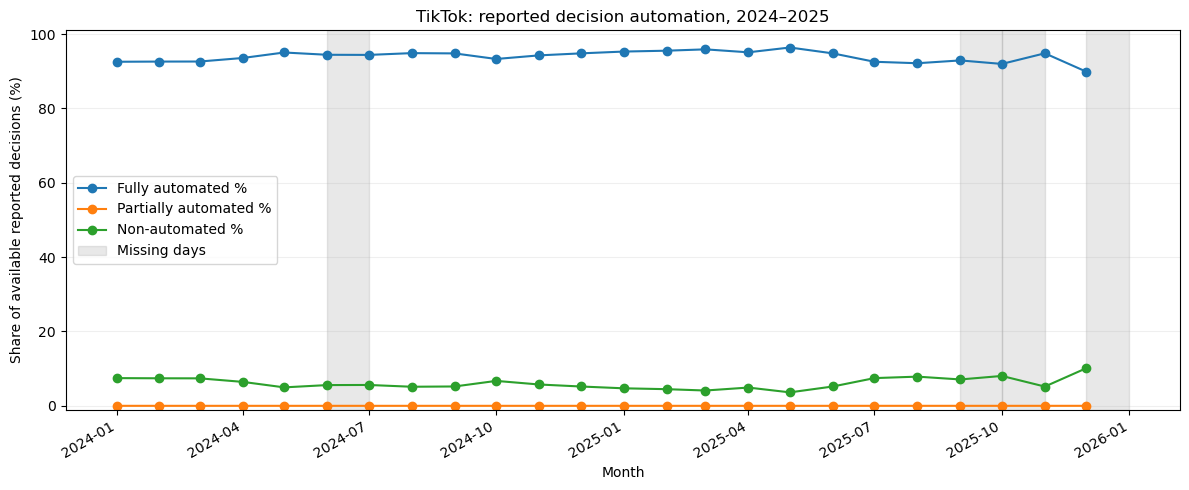

In [17]:
import matplotlib.pyplot as plt

plot_data = monthly_summary.sort_values("Month").copy()
dates = pd.to_datetime(plot_data["Month"])

fig, ax = plt.subplots(figsize=(12, 5))

for column in [
    "Fully automated %",
    "Partially automated %",
    "Non-automated %",
]:
    ax.plot(dates, plot_data[column], marker="o", label=column)

first_gap = True

for date, gap in zip(dates, plot_data["Coverage gap"]):
    if gap:
        ax.axvspan(
            date,
            date + pd.offsets.MonthBegin(1),
            color="grey",
            alpha=0.18,
            label="Missing days" if first_gap else None,
        )
        first_gap = False

ax.set(
    title="TikTok: reported decision automation, 2024–2025",
    ylabel="Share of available reported decisions (%)",
    xlabel="Month",
    ylim=(-1, 101),
)
ax.legend()
ax.grid(axis="y", alpha=0.2)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [18]:
clean_folder = project / "02_data_clean"

monthly_summary.to_csv(
    clean_folder / "tiktok_monthly_automation_2024_2025.csv",
    index=False
)

partial_by_month.to_csv(
    clean_folder / "tiktok_partial_automation_counts_2024_2025.csv",
    index=False
)

print("Saved both tables in:", clean_folder)

Saved both tables in: C:\Users\manue\.codex\.chatgpt-projects\g-p-6a6dfe28cae48191a347367c8a39fae6\Who Moderates Europe\02_data_clean


In [19]:
clean_folder = project / "02_data_clean"

monthly_summary.to_csv(
    clean_folder / "tiktok_monthly_automation_2024_2025.csv",
    index=False
)

partial_by_month.to_csv(
    clean_folder / "tiktok_partial_automation_counts_2024_2025.csv",
    index=False
)

print("Saved both tables.")

Saved both tables.


In [22]:
category_records = []

for monthly_file in files:
    year = monthly_file.name.split("-")[2]

    with ZipFile(monthly_file) as archive:
        for name in archive.namelist():
            if name.endswith(".parquet"):
                piece = pd.read_parquet(BytesIO(archive.read(name)))

                selected = piece.loc[
                    piece["platform_name"] == "TikTok"
                ]

                for category in selected["category"].dropna().unique():
                    category_records.append({
                        "Category": category,
                        "Year": year
                    })

category_presence = (
    pd.DataFrame(category_records)
    .drop_duplicates()
    .assign(Present=True)
    .pivot(index="Category", columns="Year", values="Present")
    .notna()
)

display(category_presence)

Year,2024,2025
Category,,
STATEMENT_CATEGORY_ANIMAL_WELFARE,True,True
STATEMENT_CATEGORY_CYBER_VIOLENCE,False,True
STATEMENT_CATEGORY_DATA_PROTECTION_AND_PRIVACY_VIOLATIONS,True,True
STATEMENT_CATEGORY_ILLEGAL_OR_HARMFUL_SPEECH,True,True
STATEMENT_CATEGORY_INTELLECTUAL_PROPERTY_INFRINGEMENTS,True,True
STATEMENT_CATEGORY_NEGATIVE_EFFECTS_ON_CIVIC_DISCOURSE_OR_ELECTIONS,True,True
STATEMENT_CATEGORY_NON_CONSENSUAL_BEHAVIOUR,True,True
STATEMENT_CATEGORY_OTHER_VIOLATION_TC,False,True
STATEMENT_CATEGORY_PORNOGRAPHY_OR_SEXUALIZED_CONTENT,True,True


In [23]:
chosen_categories = {
    "Illegal or harmful speech":
        "STATEMENT_CATEGORY_ILLEGAL_OR_HARMFUL_SPEECH",
    "Risk for public security":
        "STATEMENT_CATEGORY_RISK_FOR_PUBLIC_SECURITY",
    "Protection of minors":
        "STATEMENT_CATEGORY_PROTECTION_OF_MINORS",
}

monthly_presence = []

for monthly_file in files:
    month = monthly_file.name.replace(
        "aggregated-simple-", ""
    )[:7]

    categories_found = set()

    with ZipFile(monthly_file) as archive:
        for name in archive.namelist():
            if name.endswith(".parquet"):
                piece = pd.read_parquet(BytesIO(archive.read(name)))
                selected = piece.loc[
                    piece["platform_name"] == "TikTok"
                ]

                categories_found.update(
                    selected["category"].dropna().unique()
                )

    row = {"Month": month}

    for label, code in chosen_categories.items():
        row[label] = code in categories_found

    monthly_presence.append(row)

category_month_check = pd.DataFrame(monthly_presence)
display(category_month_check)

,Month,Illegal or harmful speech,Risk for public security,Protection of minors
0,2024-01,True,True,True
1,2024-02,True,True,True
2,2024-03,True,True,True
3,2024-04,True,True,True
4,2024-05,True,True,True
5,2024-06,True,True,True
6,2024-07,True,True,True
7,2024-08,True,True,True
8,2024-09,True,True,True
9,2024-10,True,True,True


In [24]:
category_results = []

for monthly_file in files:
    month = monthly_file.name.replace(
        "aggregated-simple-", ""
    )[:7]

    pieces = []

    with ZipFile(monthly_file) as archive:
        for name in archive.namelist():
            if name.endswith(".parquet"):
                piece = pd.read_parquet(BytesIO(archive.read(name)))

                selected = piece.loc[
                    (piece["platform_name"] == "TikTok")
                    & piece["category"].isin(chosen_categories.values())
                ]

                pieces.append(selected)

    month_data = pd.concat(pieces, ignore_index=True)

    for category_name, category_code in chosen_categories.items():
        category_data = month_data.loc[
            month_data["category"] == category_code
        ]

        counts = category_data.groupby(
            "automated_decision"
        )["count"].sum()

        total = category_data["count"].sum()

        row = {
            "Month": month,
            "Category": category_name,
            "Reported decisions": total,
        }

        for label, method_code in methods.items():
            row[label] = (
                counts.get(method_code, 0) / total * 100
                if total > 0 else float("nan")
            )

        category_results.append(row)

    print("Done:", month)

category_summary = pd.DataFrame(category_results)

category_summary = category_summary.merge(
    monthly_summary[
        ["Month", "Days present", "Days expected", "Coverage gap"]
    ],
    on="Month",
    how="left",
    validate="many_to_one"
)

display(category_summary.head(9).round(2))

Done: 2024-01
Done: 2024-02
Done: 2024-03
Done: 2024-04
Done: 2024-05
Done: 2024-06
Done: 2024-07
Done: 2024-08
Done: 2024-09
Done: 2024-10
Done: 2024-11
Done: 2024-12
Done: 2025-01
Done: 2025-02
Done: 2025-03
Done: 2025-04
Done: 2025-05
Done: 2025-06
Done: 2025-07
Done: 2025-08
Done: 2025-09
Done: 2025-10
Done: 2025-11
Done: 2025-12


,Month,Category,Reported decisions,Fully automated %,Partially automated %,Non-automated %,Days present,Days expected,Coverage gap
0,2024-01,Illegal or harmful speech,29398094,98.51,0.0,1.49,31,31,False
1,2024-01,Risk for public security,708,0.00,0.0,100.00,31,31,False
2,2024-01,Protection of minors,1599902,20.09,0.0,79.91,31,31,False
3,2024-02,Illegal or harmful speech,27029152,98.69,0.0,1.31,29,29,False
4,2024-02,Risk for public security,544,0.00,0.0,100.00,29,29,False
5,2024-02,Protection of minors,1642570,18.82,0.0,81.18,29,29,False
6,2024-03,Illegal or harmful speech,31990729,98.58,0.0,1.42,31,31,False
7,2024-03,Risk for public security,449,0.00,0.0,100.00,31,31,False
8,2024-03,Protection of minors,10618869,81.76,0.0,18.24,31,31,False


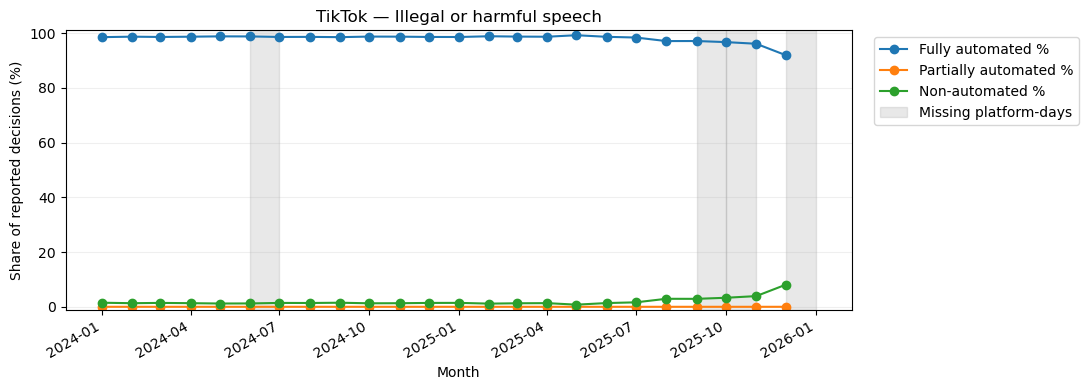

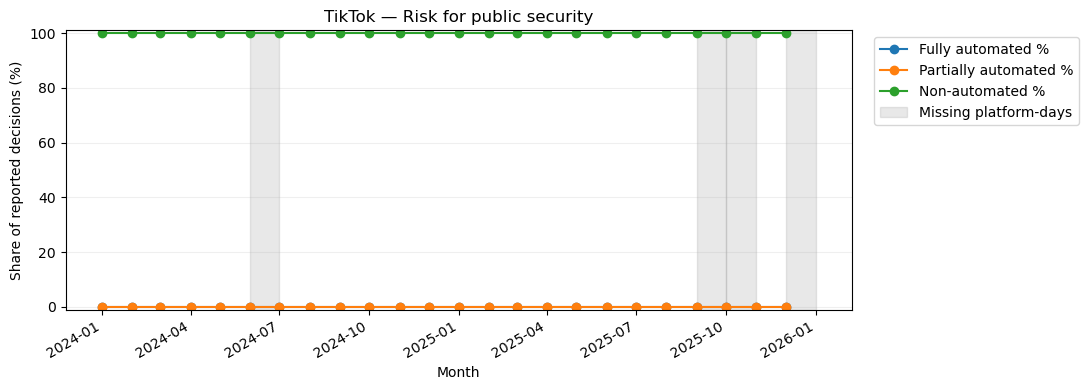

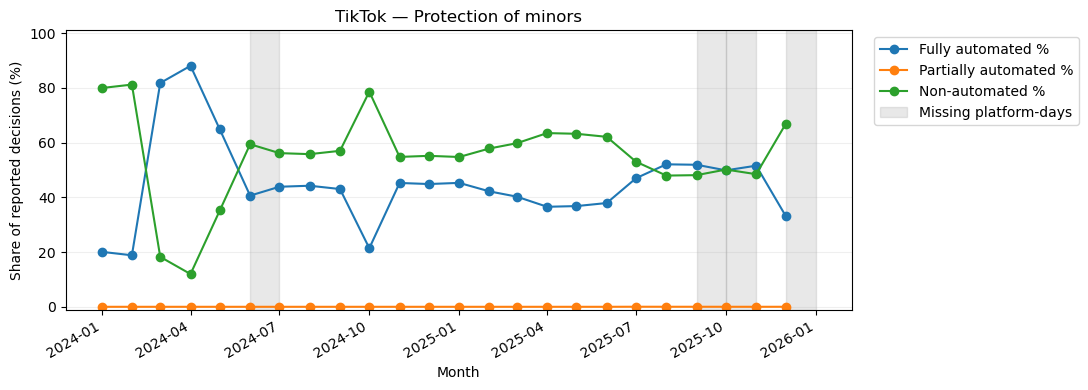

In [25]:
import matplotlib.pyplot as plt

for category_name in chosen_categories:
    chart_data = category_summary.loc[
        category_summary["Category"] == category_name
    ].sort_values("Month")

    dates = pd.to_datetime(chart_data["Month"])

    fig, ax = plt.subplots(figsize=(11, 4))

    for method in methods:
        ax.plot(
            dates,
            chart_data[method],
            marker="o",
            label=method
        )

    first_gap = True

    for date, gap in zip(dates, chart_data["Coverage gap"]):
        if gap:
            ax.axvspan(
                date,
                date + pd.offsets.MonthBegin(1),
                color="grey",
                alpha=0.18,
                label="Missing platform-days" if first_gap else None
            )
            first_gap = False

    ax.set(
        title=f"TikTok — {category_name}",
        xlabel="Month",
        ylabel="Share of reported decisions (%)",
        ylim=(-1, 101)
    )

    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
    ax.grid(axis="y", alpha=0.2)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

In [26]:
minors_check = category_summary.loc[
    (category_summary["Category"] == "Protection of minors")
    & (category_summary["Month"].between("2024-01", "2024-04")),
    [
        "Month",
        "Reported decisions",
        "Fully automated %",
        "Non-automated %",
        "Coverage gap"
    ]
]

display(minors_check.round(2))

,Month,Reported decisions,Fully automated %,Non-automated %,Coverage gap
2,2024-01,1599902,20.09,79.91,False
5,2024-02,1642570,18.82,81.18,False
8,2024-03,10618869,81.76,18.24,False
11,2024-04,10840655,88.04,11.96,False


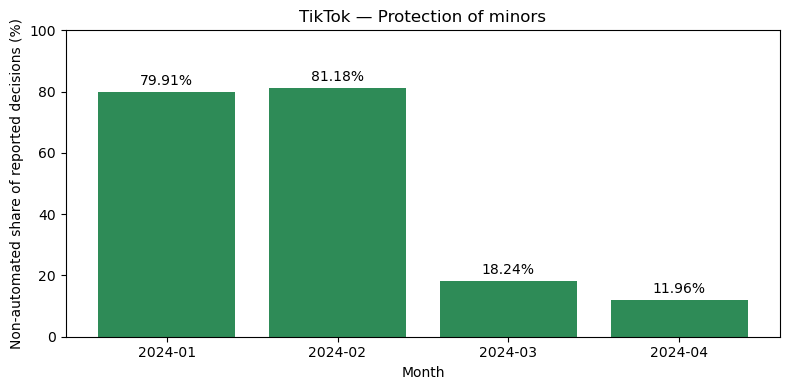

In [27]:
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(
    minors_check["Month"],
    minors_check["Non-automated %"],
    color="seagreen"
)

ax.bar_label(bars, fmt="%.2f%%", padding=3)

ax.set(
    title="TikTok — Protection of minors",
    xlabel="Month",
    ylabel="Non-automated share of reported decisions (%)",
    ylim=(0, 100)
)

plt.tight_layout()
plt.show()

In [28]:
minors_counts = minors_check.copy()

minors_counts["Non-automated decisions (approx.)"] = (
    minors_counts["Reported decisions"]
    * minors_counts["Non-automated %"] / 100
).round().astype("Int64")

display(minors_counts[
    [
        "Month",
        "Reported decisions",
        "Non-automated decisions (approx.)",
        "Non-automated %"
    ]
])

,Month,Reported decisions,Non-automated decisions (approx.),Non-automated %
2,2024-01,1599902,1278539,79.913582
5,2024-02,1642570,1333469,81.181867
8,2024-03,10618869,1937144,18.242470
11,2024-04,10840655,1297056,11.964738


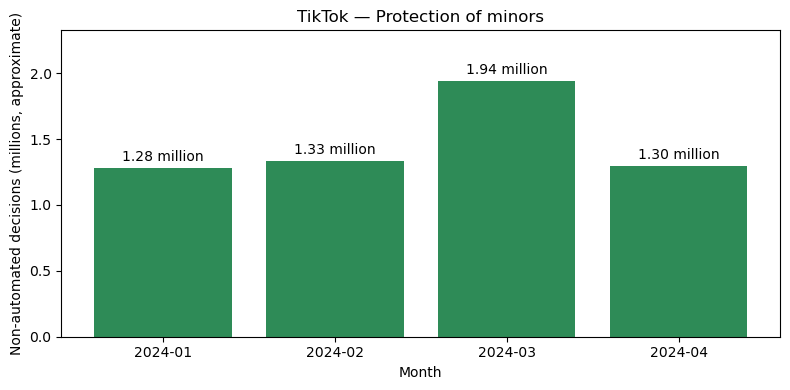

In [29]:
counts_in_millions = (
    minors_counts["Non-automated decisions (approx.)"] / 1_000_000
)

fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(
    minors_counts["Month"],
    counts_in_millions,
    color="seagreen"
)

ax.bar_label(bars, fmt="%.2f million", padding=3)

ax.set(
    title="TikTok — Protection of minors",
    xlabel="Month",
    ylabel="Non-automated decisions (millions, approximate)"
)

ax.margins(y=0.2)
plt.tight_layout()
plt.show()

In [30]:
category_summary.to_csv(
    project / "02_data_clean" / "tiktok_category_automation_2024_2025.csv",
    index=False
)

print("Saved the three-category comparison.")

Saved the three-category comparison.


In [31]:
exact_minors_rows = []

for monthly_file in files[:4]:
    month = monthly_file.name.replace("aggregated-simple-", "")[:7]

    with ZipFile(monthly_file) as archive:
        for name in archive.namelist():
            if name.endswith(".parquet"):
                piece = pd.read_parquet(BytesIO(archive.read(name)))

                selected = piece.loc[
                    (piece["platform_name"] == "TikTok")
                    & (
                        piece["category"]
                        == "STATEMENT_CATEGORY_PROTECTION_OF_MINORS"
                    ),
                    ["automated_decision", "count"]
                ].copy()

                selected["Month"] = month
                exact_minors_rows.append(selected)

exact_minors = (
    pd.concat(exact_minors_rows, ignore_index=True)
    .groupby(["Month", "automated_decision"])["count"]
    .sum()
    .unstack(fill_value=0)
)

display(exact_minors)

automated_decision,AUTOMATED_DECISION_FULLY,AUTOMATED_DECISION_NOT_AUTOMATED
Month,,
2024-01,321363,1278539
2024-02,309101,1333469
2024-03,8681725,1937144
2024-04,9543599,1297056


In [32]:
comparison = minors_counts.set_index("Month")[
    ["Non-automated decisions (approx.)"]
].join(
    exact_minors["AUTOMATED_DECISION_NOT_AUTOMATED"]
    .rename("Exact non-automated decisions")
)

comparison["Match"] = (
    comparison["Non-automated decisions (approx.)"]
    == comparison["Exact non-automated decisions"]
)

display(comparison)

,Non-automated decisions (approx.),Exact non-automated decisions,Match
Month,,,
2024-01,1278539,1278539,True
2024-02,1333469,1333469,True
2024-03,1937144,1937144,True
2024-04,1297056,1297056,True


In [33]:
exact_minors.to_csv(
    project / "02_data_clean" / "tiktok_minors_exact_counts_jan_apr_2024.csv"
)

print("Exact counts saved.")

Exact counts saved.


In [34]:
action_rows = []

for monthly_file in files[1:3]:
    month = monthly_file.name.replace("aggregated-simple-", "")[:7]

    with ZipFile(monthly_file) as archive:
        for name in archive.namelist():
            if name.endswith(".parquet"):
                piece = pd.read_parquet(BytesIO(archive.read(name)))

                selected = piece.loc[
                    (piece["platform_name"] == "TikTok")
                    & (
                        piece["category"]
                        == "STATEMENT_CATEGORY_PROTECTION_OF_MINORS"
                    )
                ].copy()

                selected["Month"] = month
                action_rows.append(selected)

minors_actions = pd.concat(action_rows, ignore_index=True)

visibility_actions = {
    "Removal": "DECISION_VISIBILITY_CONTENT_REMOVED",
    "Access disabled": "DECISION_VISIBILITY_CONTENT_DISABLED",
    "Demotion": "DECISION_VISIBILITY_CONTENT_DEMOTED",
    "Age restriction": "DECISION_VISIBILITY_CONTENT_AGE_RESTRICTED",
    "Interaction restriction": "DECISION_VISIBILITY_CONTENT_INTERACTION_RESTRICTED",
    "Labelling": "DECISION_VISIBILITY_CONTENT_LABELLED",
    "Other visibility action": "DECISION_VISIBILITY_OTHER",
}

action_counts = {}

for label, column in visibility_actions.items():
    action_counts[label] = (
        minors_actions.loc[minors_actions[column] == True]
        .groupby("Month")["count"]
        .sum()
    )

action_comparison = (
    pd.DataFrame(action_counts)
    .reindex(["2024-02", "2024-03"])
    .fillna(0)
    .astype("int64")
    .T
)

display(action_comparison)

Month,2024-02,2024-03
Removal,391539,451056
Access disabled,190,646
Demotion,0,0
Age restriction,1029785,1450819
Interaction restriction,0,0
Labelling,0,0
Other visibility action,125205,8611238


In [35]:
action_method_tables = []

for action_name, column in visibility_actions.items():
    selected = minors_actions.loc[
        minors_actions[column] == True
    ]

    counts = (
        selected
        .groupby(["Month", "automated_decision"])["count"]
        .sum()
        .reset_index()
    )

    counts["Action"] = action_name
    action_method_tables.append(counts)

action_by_method = pd.concat(
    action_method_tables,
    ignore_index=True
)

action_method_comparison = action_by_method.pivot_table(
    index=["Action", "automated_decision"],
    columns="Month",
    values="count",
    aggfunc="sum",
    fill_value=0
)

display(action_method_comparison)

Month                                                     2024-02  2024-03
Action                  automated_decision                                
Access disabled         AUTOMATED_DECISION_NOT_AUTOMATED      190      646
Age restriction         AUTOMATED_DECISION_FULLY              149     1288
                        AUTOMATED_DECISION_NOT_AUTOMATED  1029636  1449531
Other visibility action AUTOMATED_DECISION_FULLY              155  8312486
                        AUTOMATED_DECISION_NOT_AUTOMATED   125050   298752
Removal                 AUTOMATED_DECISION_FULLY           308946   368244
                        AUTOMATED_DECISION_NOT_AUTOMATED    82593    82812

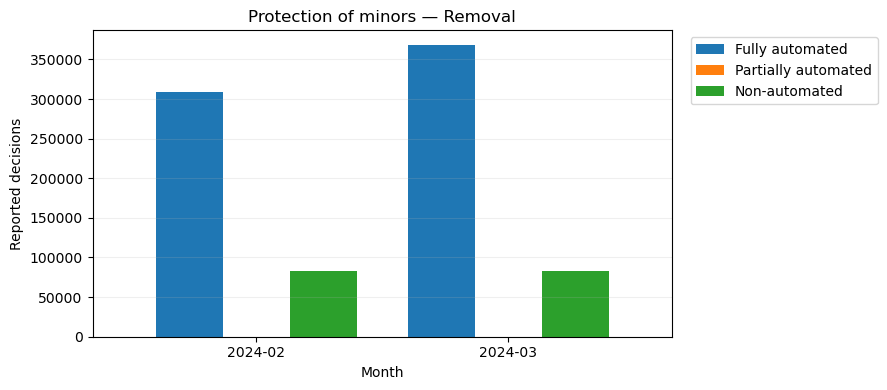

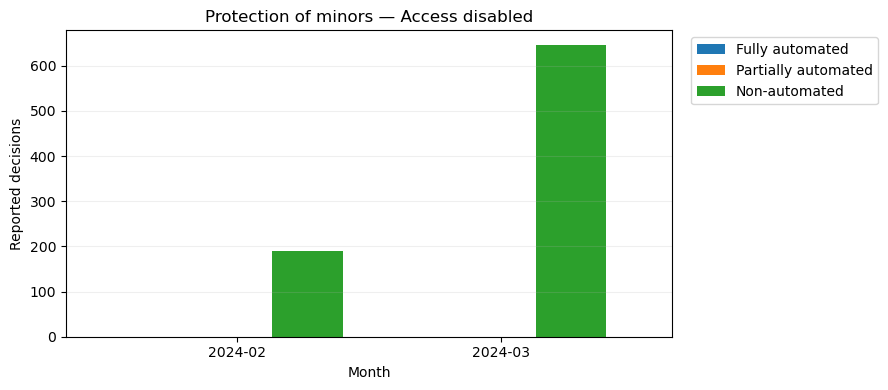

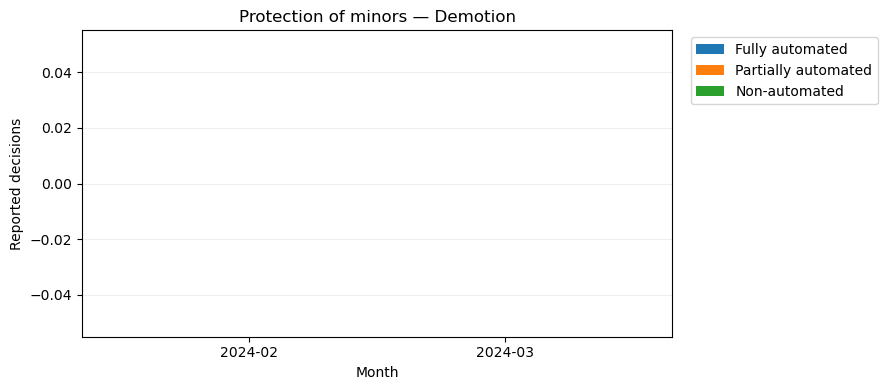

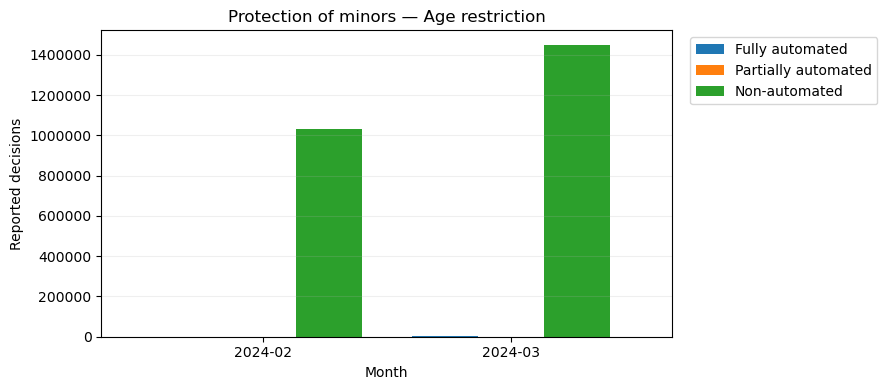

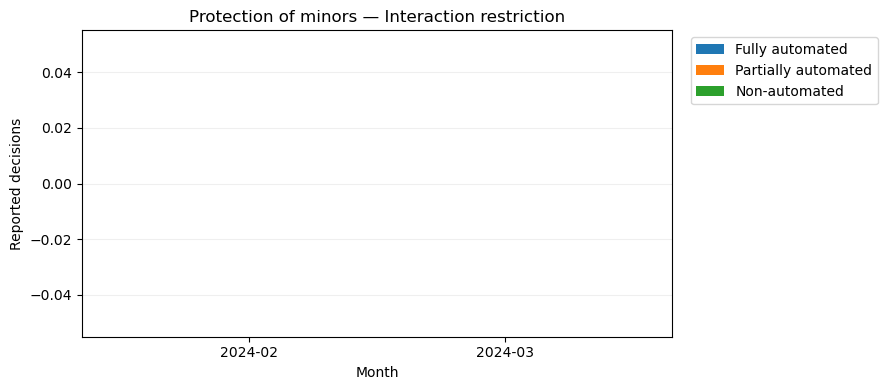

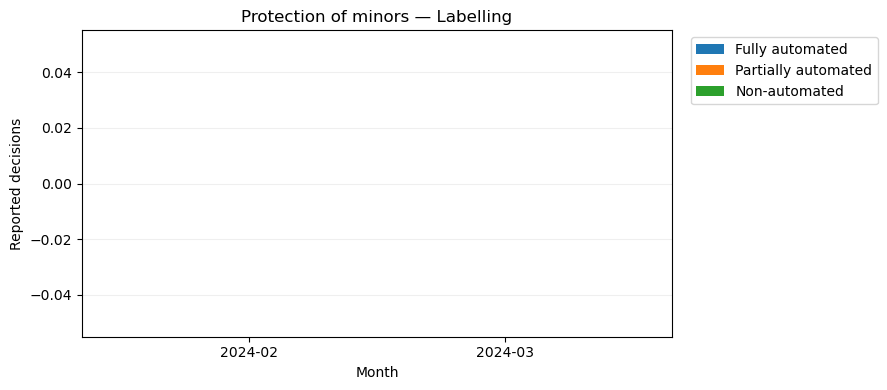

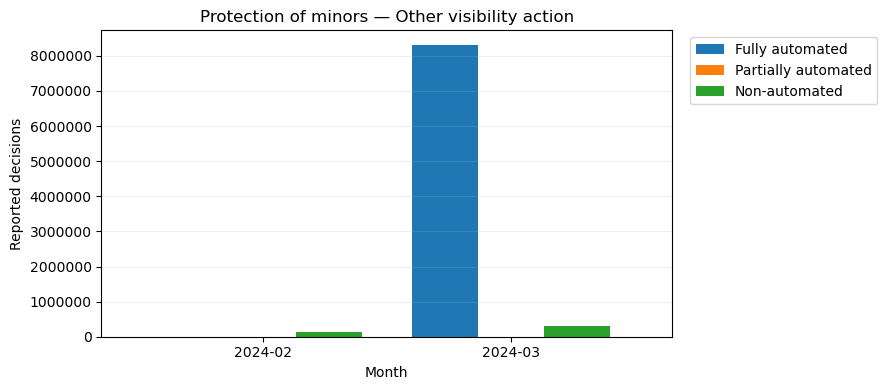

In [36]:
method_names = {
    "AUTOMATED_DECISION_FULLY": "Fully automated",
    "AUTOMATED_DECISION_PARTIALLY": "Partially automated",
    "AUTOMATED_DECISION_NOT_AUTOMATED": "Non-automated",
}

for action_name in visibility_actions:
    selected = action_by_method.loc[
        action_by_method["Action"] == action_name
    ]

    bars = selected.pivot_table(
        index="Month",
        columns="automated_decision",
        values="count",
        aggfunc="sum",
        fill_value=0
    )

    bars = bars.reindex(
        index=["2024-02", "2024-03"],
        columns=list(method_names),
        fill_value=0
    ).fillna(0)

    bars = bars.rename(columns=method_names)

    ax = bars.plot.bar(
        figsize=(9, 4),
        color=["tab:blue", "tab:orange", "tab:green"],
        width=0.8
    )

    ax.set(
        title=f"Protection of minors — {action_name}",
        xlabel="Month",
        ylabel="Reported decisions",
    )

    ax.tick_params(axis="x", rotation=0)
    ax.ticklabel_format(axis="y", style="plain")
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
    ax.grid(axis="y", alpha=0.2)

    plt.tight_layout()
    plt.show()

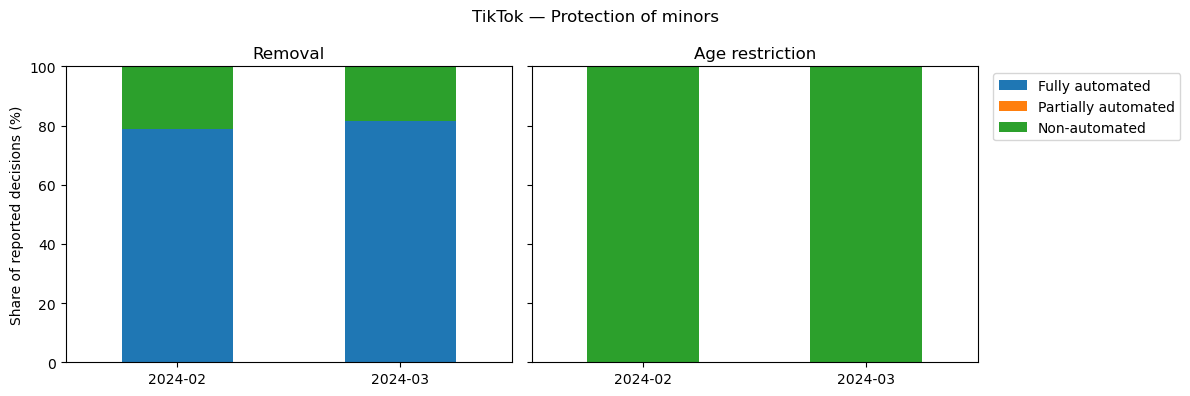

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, action in zip(axes, ["Removal", "Age restriction"]):
    selected = action_by_method.loc[
        action_by_method["Action"] == action
    ]

    counts = selected.pivot_table(
        index="Month",
        columns="automated_decision",
        values="count",
        aggfunc="sum",
        fill_value=0
    )

    counts = counts.reindex(
        index=["2024-02", "2024-03"],
        columns=list(method_names),
        fill_value=0
    ).fillna(0)

    totals = counts.sum(axis=1).replace(0, float("nan"))
    percentages = counts.div(totals, axis=0) * 100

    percentages.rename(columns=method_names).plot.bar(
        stacked=True,
        ax=ax,
        color=["tab:blue", "tab:orange", "tab:green"],
        legend=False
    )

    ax.set_title(action)
    ax.set_xlabel("")
    ax.set_ylim(0, 100)
    ax.tick_params(axis="x", rotation=0)

axes[0].set_ylabel("Share of reported decisions (%)")
axes[1].legend(loc="upper left", bbox_to_anchor=(1.02, 1))

fig.suptitle("TikTok — Protection of minors")
plt.tight_layout()
plt.show()

In [37]:
action_by_method.to_csv(
    project / "02_data_clean" / "tiktok_minors_actions_feb_mar_2024.csv",
    index=False
)

print("Action comparison saved.")

Action comparison saved.


In [39]:
coverage_results = []

for version in ["All available months", "Months without day gaps"]:
    data = category_summary.copy()

    if version == "Months without day gaps":
        data = data.loc[data["Coverage gap"] == False]

    data["Year"] = data["Month"].str[:4]

    for (year, category), group in data.groupby(["Year", "Category"]):
        total = group["Reported decisions"].sum()

        row = {
            "Year": year,
            "Category": category,
            "Comparison": version,
            "Months included": len(group),
        }

        for method in methods:
            row[method] = (
                (group[method] * group["Reported decisions"]).sum()
                / total
                if total > 0 else float("nan")
            )

        coverage_results.append(row)

coverage_comparison = pd.DataFrame(coverage_results)

display(
    coverage_comparison
    .sort_values(["Category", "Year", "Comparison"])
    .round(2)
)

,Year,Category,Comparison,Months included,Fully automated %,Partially automated %,Non-automated %
0,2024,Illegal or harmful speech,All available months,12,98.64,0.0,1.36
6,2024,Illegal or harmful speech,Months without day gaps,11,98.63,0.0,1.37
3,2025,Illegal or harmful speech,All available months,12,98.62,0.0,1.38
9,2025,Illegal or harmful speech,Months without day gaps,9,98.70,0.0,1.30
1,2024,Protection of minors,All available months,12,63.86,0.0,36.14
7,2024,Protection of minors,Months without day gaps,11,64.83,0.0,35.17
4,2025,Protection of minors,All available months,12,41.52,0.0,58.48
10,2025,Protection of minors,Months without day gaps,9,41.08,0.0,58.91
2,2024,Risk for public security,All available months,12,0.00,0.0,100.00
8,2024,Risk for public security,Months without day gaps,11,0.00,0.0,100.00


In [40]:
coverage_comparison.to_csv(
    project / "02_data_clean" / "tiktok_coverage_sensitivity_2024_2025.csv",
    index=False
)

print("Coverage comparison saved.")

Coverage comparison saved.


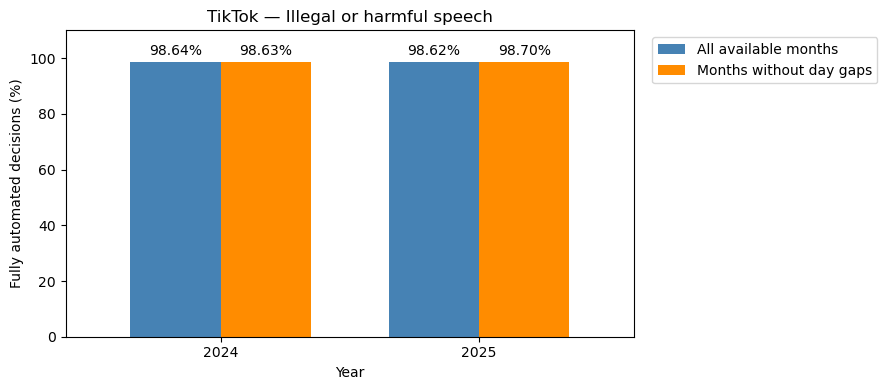

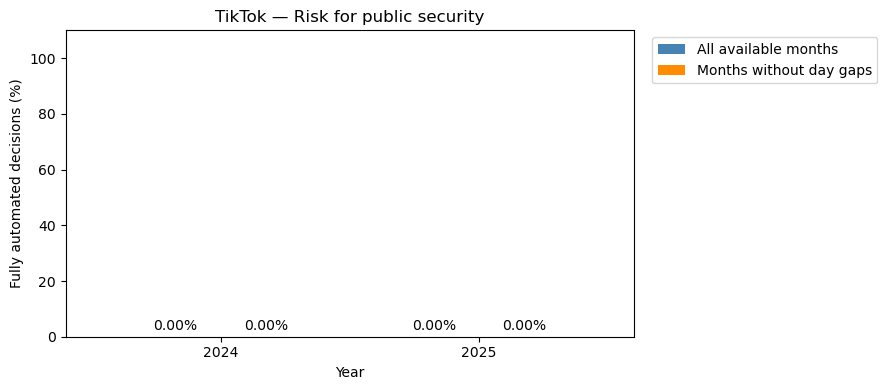

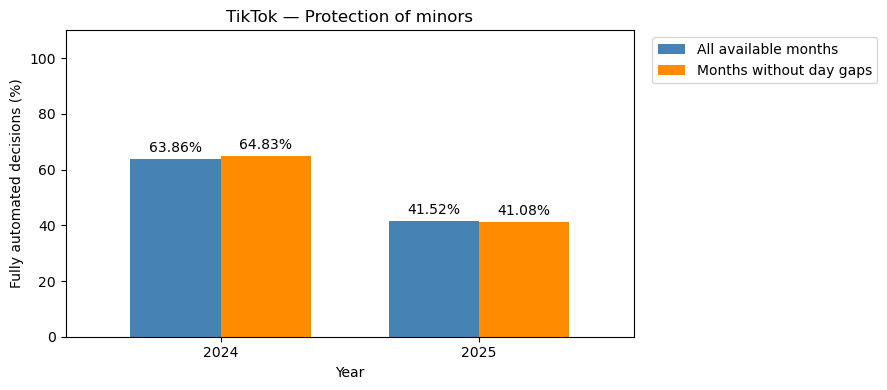

In [41]:
for category in chosen_categories:
    selected = coverage_comparison.loc[
        coverage_comparison["Category"] == category
    ]

    chart = selected.pivot(
        index="Year",
        columns="Comparison",
        values="Fully automated %"
    )

    chart = chart[
        ["All available months", "Months without day gaps"]
    ]

    ax = chart.plot.bar(
        figsize=(9, 4),
        color=["steelblue", "darkorange"],
        width=0.7
    )

    for bars in ax.containers:
        ax.bar_label(bars, fmt="%.2f%%", padding=3)

    ax.set(
        title=f"TikTok — {category}",
        xlabel="Year",
        ylabel="Fully automated decisions (%)",
        ylim=(0, 110)
    )

    ax.tick_params(axis="x", rotation=0)
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
    plt.tight_layout()
    plt.show()